In [20]:
import numpy as np
import matplotlib.pyplot as plt

In [21]:
def calc_population(P0, K, kR, times_list):
    A = (K - P0)/P0
    pop_list = (K/(1 + A*np.exp(-kR*(times_list-times_list[0]))))
    return pop_list

In [22]:
t_list = np.arange(1800,2101,10)

P0 = 1
K = 10
kR = 0.016

normal_pop = calc_population(P0,K,kR,t_list)


(0.0, 10.0)

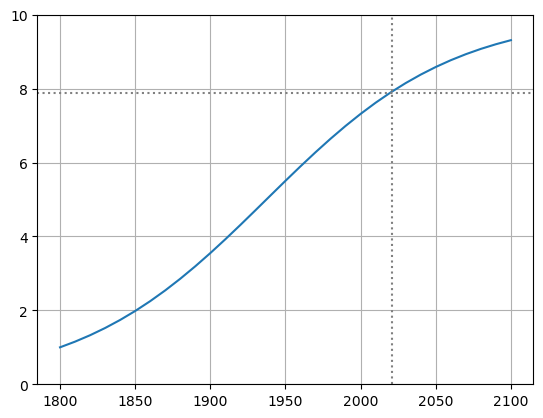

In [23]:
plt.plot(t_list,normal_pop)
plt.axvline(2021, color="0.5", ls=":")
plt.axhline(7.888, color="0.5", ls=":")
plt.grid()
plt.ylim(0,10)

In [24]:
P0 = 1
K = np.ones(len(t_list)) * 10.0
K[t_list > 2000] = K[t_list > 2000]+(-1.0*(np.linspace(0, -1.25, len(np.where(t_list > 2000)[0])))**2)
kR = 0.016

pop = calc_population(P0,K,kR,t_list)

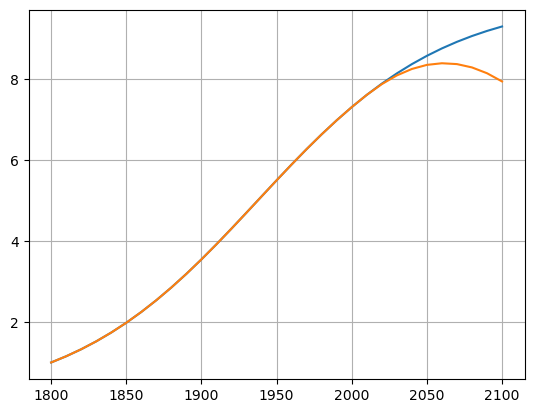

In [25]:
plt.plot(t_list, normal_pop)
plt.plot(t_list,pop)
plt.grid()

(0.0, 10.0)

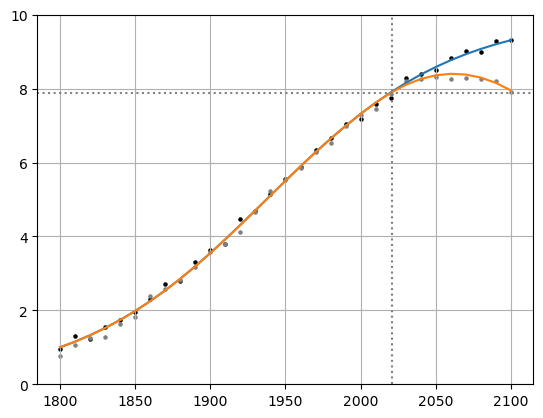

In [26]:
normal_pop_w_noise = normal_pop + np.random.normal(size=len(pop))/10
pop_w_noise = pop + np.random.normal(size=len(pop))/10

plt.plot(t_list, normal_pop)
plt.plot(t_list,pop)
plt.scatter(t_list, normal_pop_w_noise, s=5, c='k')
plt.scatter(t_list, pop_w_noise, s=5, c='0.5')
plt.axvline(2021, color="0.5", ls=":")
plt.axhline(7.888, color="0.5", ls=":")
plt.grid()
plt.ylim(0,10)

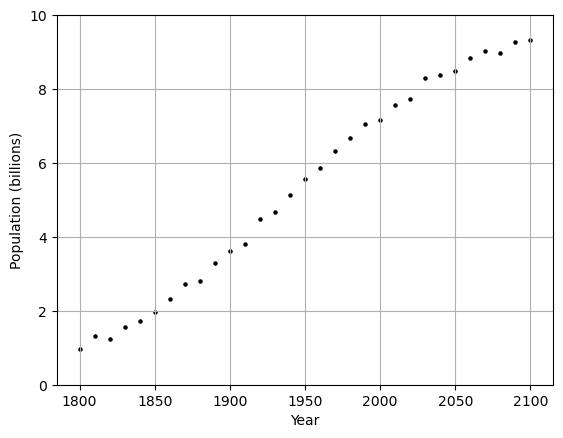

In [27]:
#plt.plot(t_list, normal_pop)
#plt.plot(t_list,pop)
plt.scatter(t_list, normal_pop_w_noise, s=5, c='k')
plt.grid()
plt.ylim(0,10)
plt.xlabel("Year")
plt.ylabel("Population (billions)")
plt.savefig("data_plot.png")

In [28]:
np.savetxt("pop_data.csv", np.array([t_list,normal_pop_w_noise,pop_w_noise]).T, delimiter=",",
           header="time, pop_model_1, pop_model_2", comments="", fmt=['%i','%f','%f'])